Environment Setup & Data Loading

In [2]:
import torch
import pandas as pd
import os
from google.colab import drive

drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/resources/ml-100k/ml-100k'

print(f"Looking for data in: {dataset_path}")
if not os.path.exists(f"{dataset_path}/u.data"):
    print(f"ERROR!! Couldn't find 'u.data' in {dataset_path}")
else:
    print("SUCCESS!! Data found!")

col_names = ['userId', 'movieId', 'rating', 'timestamp']
all_data = pd.read_csv(f"{dataset_path}/u.data", sep='\t', names=col_names)

print("\nPREVIEW OF RAW DATA")
print(all_data.head())
print("-" * 30)

#Mappingss
user_ids = all_data['userId'].unique()
movie_ids = all_data['movieId'].unique()

user_map = {id: i for i, id in enumerate(user_ids)}
movie_map = {id: i for i, id in enumerate(movie_ids)}

num_user = len(user_ids)
num_items = len(movie_ids)
print(f"\nStats: Found {num_user} Users and {num_items} Movies.")

#GPU optimization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"processing on {device}")

def load_to_gpu(filename):
  path =f"{dataset_path}/{filename}"
  df = pd.read_csv(path, sep='\t', names=col_names)

  u = torch.LongTensor(df['userId'].map(user_map).fillna(0).values).to(device)
  i = torch.LongTensor(df['movieId'].map(movie_map).fillna(0).values).to(device)
  r = torch.FloatTensor(df['rating'].values).to(device)

  return u, i, r

print("\nloading u1.base and u1.test to GPU memo")
train_u, train_i, train_r = load_to_gpu('u1.base')
test_u, test_i, test_r = load_to_gpu('u1.test')

print("SUCCESS!!! Data Loaded and Ready on GPU.")
print(f"Train Size: {len(train_u)} ratings")
print(f"Test Size: {len(test_u)} ratings")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking for data in: /content/drive/MyDrive/resources/ml-100k/ml-100k
SUCCESS!! Data found!

PREVIEW OF RAW DATA
   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
------------------------------

Stats: Found 943 Users and 1682 Movies.
processing on cuda

loading u1.base and u1.test to GPU memo
SUCCESS!!! Data Loaded and Ready on GPU.
Train Size: 80000 ratings
Test Size: 20000 ratings


In [3]:
#Model definitions
import torch.nn as nn

#Bias only model for baseline
class BiasOnlyModel(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=None):
        super().__init__()
        self.global_bias = nn.Parameter(torch.zeros(1))
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)

    def forward(self, user, item):
        return self.global_bias + self.user_bias(user).squeeze() + self.item_bias(item).squeeze()

#Matrix Factorization model no bias
class MatrixFactorizationModel(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, embedding_dim)
        self.item_embed = nn.Embedding(n_items, embedding_dim)
        # Xavier Initialization (Helps learning start faster)
        nn.init.xavier_uniform_(self.user_embed.weight)
        nn.init.xavier_uniform_(self.item_embed.weight)

    def forward(self, user, item):
        return (self.user_embed(user) * self.item_embed(item)).sum(1)

#Matrix Factorization with bias
class MatrixFactorizationWithBiasModel(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, embedding_dim)
        self.item_embed = nn.Embedding(n_items, embedding_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        # Initialization
        nn.init.xavier_uniform_(self.user_embed.weight)
        nn.init.xavier_uniform_(self.item_embed.weight)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user, item):
        dot = (self.user_embed(user) * self.item_embed(item)).sum(1)
        bias = self.global_bias + self.user_bias(user).squeeze() + self.item_bias(item).squeeze()
        return dot + bias

#Neural Collabriative Model NCF
class NeuralCollaborativeFilteringModel(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, embedding_dim)
        self.item_embed = nn.Embedding(n_items, embedding_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        # The Neural Network Layers
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, 1)
        )
        # He Initialization (Best for ReLU networks)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self, user, item):
        cat = torch.cat([self.user_embed(user), self.item_embed(item)], dim=1)
        score = self.mlp(cat).squeeze()
        bias = self.global_bias + self.user_bias(user).squeeze() + self.item_bias(item).squeeze()
        return score + bias

#NCF with no bias
class NCFWithoutBiasModel(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, embedding_dim)
        self.item_embed = nn.Embedding(n_items, embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, 1)
        )
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self, user, item):
        cat = torch.cat([self.user_embed(user), self.item_embed(item)], dim=1)
        return self.mlp(cat).squeeze()

print("models defined")

models defined


Main Grid Search

In [21]:
from itertools import product
import torch.optim as optim
import time

#parameters
embedding_dims = [8, 16, 32, 64, 128]
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
regularizations = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]

grid_combinations = list(product(embedding_dims, learning_rates, regularizations))

print(f"Testing {len(grid_combinations)} combinations on {device}...")
print(f"Model: Matrix Factorization With Bias")
print(f"{'Dim':<5} {'LR':<7} {'Reg':<8} {'RMSE':<10} {'Time':<6}")

grid_results = []
best_rmse = float('inf')
golden_config = {}


for dim, lr, reg in grid_combinations:
    start_time = time.time()

    model = MatrixFactorizationWithBiasModel(num_user, num_items, dim).to(device)

    #Optimizer(AdamW) & Scheduler(ReduceLROnPlateau)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=reg)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    #Early Stopping
    best_loss_run = float('inf')
    patience_counter = 0
    patience_limit = 3
    max_epochs = 100

    model.train()

    for epoch in range(max_epochs):
        optimizer.zero_grad()
        preds = model(train_u, train_i)
        loss = criterion(preds, train_r)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(test_u, test_i)
            val_mse = criterion(val_preds, test_r)
            val_rmse = torch.sqrt(val_mse).item()
        model.train()

        scheduler.step(val_rmse)

        if val_rmse < best_loss_run:
            best_loss_run = val_rmse
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                break

    elapsed = time.time() - start_time

    grid_results.append({
        'dim': dim, 'lr': lr, 'reg': reg, 'rmse': best_loss_run
    })

    print(f"{dim:<5} {lr:<7} {reg:<8} {best_loss_run:.4f}      {elapsed:.0f}s")

    if best_loss_run < best_rmse:
        best_rmse = best_loss_run
        golden_config = {'dim': dim, 'lr': lr, 'reg': reg}
        winner_history = current_run_history[:]

print("\nMain Grid Search completed")
print(f"Winner: Dim={golden_config['dim']}, LR={golden_config['lr']}, Reg={golden_config['reg']}")
print(f"Lowest RMSE: {best_rmse:.4f}")


df_results = pd.DataFrame(grid_results)
if os.path.exists('/content/drive/MyDrive'):
    save_loc = '/content/drive/MyDrive/resources/processed_for_colab/grid_results.csv'
    df_results.to_csv(save_loc, index=False)
    print(f"results saved to {save_loc}")
else:
    print("results saved locally")

Testing 125 combinations on cuda...
Model: Matrix Factorization With Bias
Dim   LR      Reg      RMSE       Time  
8     0.001   0.0      3.3241      0s
8     0.001   1e-06    3.3154      0s
8     0.001   1e-05    3.3132      0s
8     0.001   0.0001   3.3228      0s
8     0.001   0.001    3.3167      0s
8     0.005   0.0      1.0502      0s
8     0.005   1e-06    1.0619      0s
8     0.005   1e-05    1.0223      0s
8     0.005   0.0001   1.0225      0s
8     0.005   0.001    1.0256      0s
8     0.01    0.0      0.9633      0s
8     0.01    1e-06    0.9679      0s
8     0.01    1e-05    0.9650      0s
8     0.01    0.0001   0.9630      0s
8     0.01    0.001    0.9541      0s
8     0.05    0.0      1.1150      0s
8     0.05    1e-06    1.1318      0s
8     0.05    1e-05    1.1391      0s
8     0.05    0.0001   1.1031      0s
8     0.05    0.001    1.1082      0s
8     0.1     0.0      1.1491      0s
8     0.1     1e-06    1.1766      0s
8     0.1     1e-05    1.1039      0s
8     0.1  

Model Comparasion

Using Optimal Configurations: Dim=32, LR=0.005, Reg=1e-06
Model Name                          RMSE       Time  
BiasOnlyModel                       2.7879      0s
MatrixFactorizationModel            0.9640      0s
MatrixFactorizationWithBiasModel    0.9602      0s
NCFWithoutBiasModel                 1.6069      0s
NeuralCollaborativeFilteringModel   1.7150      0s

Model Comparison completed
Winner: MatrixFactorizationWithBiasModel (RMSE: 0.9602)
results saved to /content/drive/MyDrive/resources/processed_for_colab/model_comparison_results.csv
Comparison Plot saved to: /content/drive/MyDrive/resources/processed_for_colab/all_models_learning_curve.png


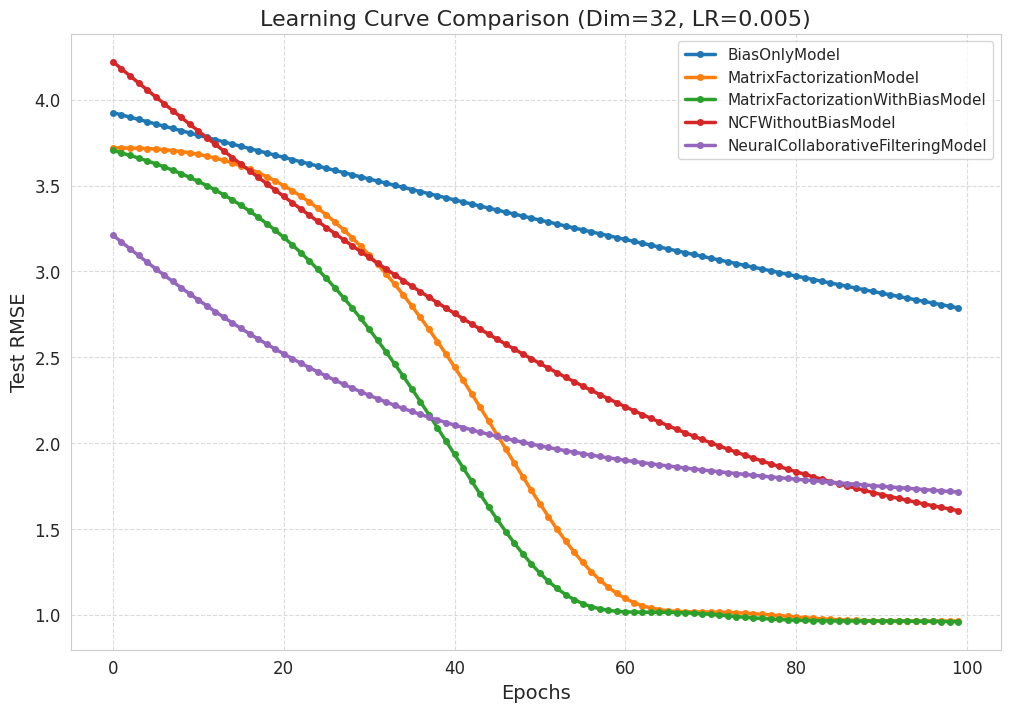

In [22]:
from IPython.core import history
import matplotlib.pyplot as plt
import seaborn as sns

OPTIMAL_DIM = 32
OPTIMAL_LR = 0.005
OPTIMAL_REG = 1e-06

print(f"Using Optimal Configurations: Dim={OPTIMAL_DIM}, LR={OPTIMAL_LR}, Reg={OPTIMAL_REG}")
print(f"{'Model Name':<35} {'RMSE':<10} {'Time':<6}")

model_results = []
history = {}
models_to_test = [
    ("BiasOnlyModel", BiasOnlyModel(num_user, num_items)),
    ("MatrixFactorizationModel", MatrixFactorizationModel(num_user, num_items, OPTIMAL_DIM)),
    ("MatrixFactorizationWithBiasModel", MatrixFactorizationWithBiasModel(num_user, num_items, OPTIMAL_DIM)),
    ("NCFWithoutBiasModel", NCFWithoutBiasModel(num_user, num_items, OPTIMAL_DIM)),
    ("NeuralCollaborativeFilteringModel", NeuralCollaborativeFilteringModel(num_user, num_items, OPTIMAL_DIM))
]

for name, model in models_to_test:
    start_time = time.time()
    model = model.to(device)

    #special config: NNs often need lower LR than MF
    current_lr = 0.001 if "NCF" in name or "Neural" in name else OPTIMAL_LR

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=current_lr, weight_decay=OPTIMAL_REG)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_loss_run = float('inf')
    max_epochs = 100
    patience_limit = 5
    patience_counter = 0

    epoch_rmse_list = []
    model.train()

    for epoch in range(max_epochs):
        optimizer.zero_grad()
        preds = model(train_u, train_i)
        loss = criterion(preds, train_r)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(test_u, test_i)
            val_mse = criterion(val_preds, test_r)
            val_rmse = torch.sqrt(val_mse).item()
        model.train()

        epoch_rmse_list.append(val_rmse)
        scheduler.step(val_rmse)

        if val_rmse < best_loss_run:
            best_loss_run = val_rmse
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                break

    elapsed = time.time() - start_time

    history[name] = epoch_rmse_list
    model_results.append({'Model': name, 'RMSE': best_loss_run})
    print(f"{name:<35} {best_loss_run:.4f}      {elapsed:.0f}s")

print("\nModel Comparison completed")
model_results.sort(key=lambda x: x['RMSE'])
print(f"Winner: {model_results[0]['Model']} (RMSE: {model_results[0]['RMSE']:.4f})")

df_arch = pd.DataFrame(model_results)
save_path = '/content/drive/MyDrive/resources/processed_for_colab/model_comparison_results.csv'
if os.path.exists('/content/drive/MyDrive'):
    df_arch.to_csv(save_path, index=False)
    print(f"results saved to {save_path}")

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

for name, curve in history.items():
    plt.plot(curve, label=name, linewidth=2.5, marker='o', markersize=4)

plt.title(f'Learning Curve Comparison (Dim={OPTIMAL_DIM}, LR={OPTIMAL_LR})', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Test RMSE', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

save_path = '/content/drive/MyDrive/resources/processed_for_colab/all_models_learning_curve.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Comparison Plot saved to: {save_path}")
plt.show()

Cross-Validation

In [26]:
import numpy as np

MODEL_CLASS = MatrixFactorizationWithBiasModel
CV_DIM = 32
CV_LR = 0.005
CV_REG = 1e-06

print(f"Model: {MODEL_CLASS.__name__}")
print(f"Config: Dim={CV_DIM}, LR={CV_LR}, Reg={CV_REG}")
print("-" * 65)
print(f"{'Fold':<6} {'RMSE':<10} {'Time':<6}")

cv_results = []

folds = [1, 2, 3, 4, 5]

for k in folds:
    start_time = time.time()

    train_file = f'u{k}.base'
    test_file = f'u{k}.test'

    u_train, i_train, r_train = load_to_gpu(train_file)
    u_test, i_test, r_test = load_to_gpu(test_file)

    model = MODEL_CLASS(num_user, num_items, CV_DIM).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=CV_LR, weight_decay=CV_REG)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_fold_rmse = float('inf')
    patience = 0
    limit = 3

    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        preds = model(u_train, i_train)
        loss = criterion(preds, r_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(u_test, i_test)
            val_mse = criterion(val_preds, r_test)
            val_rmse = torch.sqrt(val_mse).item()
        model.train()

        scheduler.step(val_rmse)
        if val_rmse < best_fold_rmse:
            best_fold_rmse = val_rmse
            patience = 0
        else:
            patience += 1
            if patience >= limit:
                break

    elapsed = time.time() - start_time
    cv_results.append(best_fold_rmse)

    print(f"Fold {k}  {best_fold_rmse:.4f}      {elapsed:.0f}s")


avg_rmse = np.mean(cv_results)
std_rmse = np.std(cv_results)

print("cross-validation completed")
print(f"Final Report Score is {avg_rmse:.4f} ± {std_rmse:.4f}")

df_cv = pd.DataFrame({'Fold': folds, 'RMSE': cv_results})
save_path = '/content/drive/MyDrive/resources/processed_for_colab/cv_results.csv'
if os.path.exists('/content/drive/MyDrive'):
    df_cv.to_csv(save_path, index=False)
    print(f"results saved to {save_path}")

Model: MatrixFactorizationWithBiasModel
Config: Dim=32, LR=0.005, Reg=1e-06
-----------------------------------------------------------------
Fold   RMSE       Time  
Fold 1  0.9502      1s
Fold 2  0.9362      1s
Fold 3  1.0016      0s
Fold 4  0.9373      1s
Fold 5  0.9353      1s
cross-validation completed
Final Report Score is 0.9521 ± 0.0253
results saved to /content/drive/MyDrive/resources/processed_for_colab/cv_results.csv


visualization

data Loaded for visualization
Plot 1 Saved: /content/drive/MyDrive/resources/processed_for_colab/heatmap_lr_reg.png


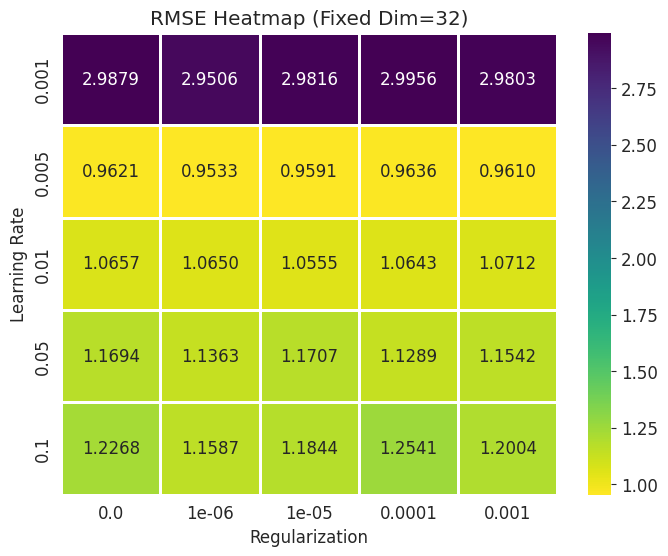

/tmp/ipython-input-950523399.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='RMSE', y='Model', data=df_models, palette='mako')


Plot 2 Saved /content/drive/MyDrive/resources/processed_for_colab/model_comparison.png


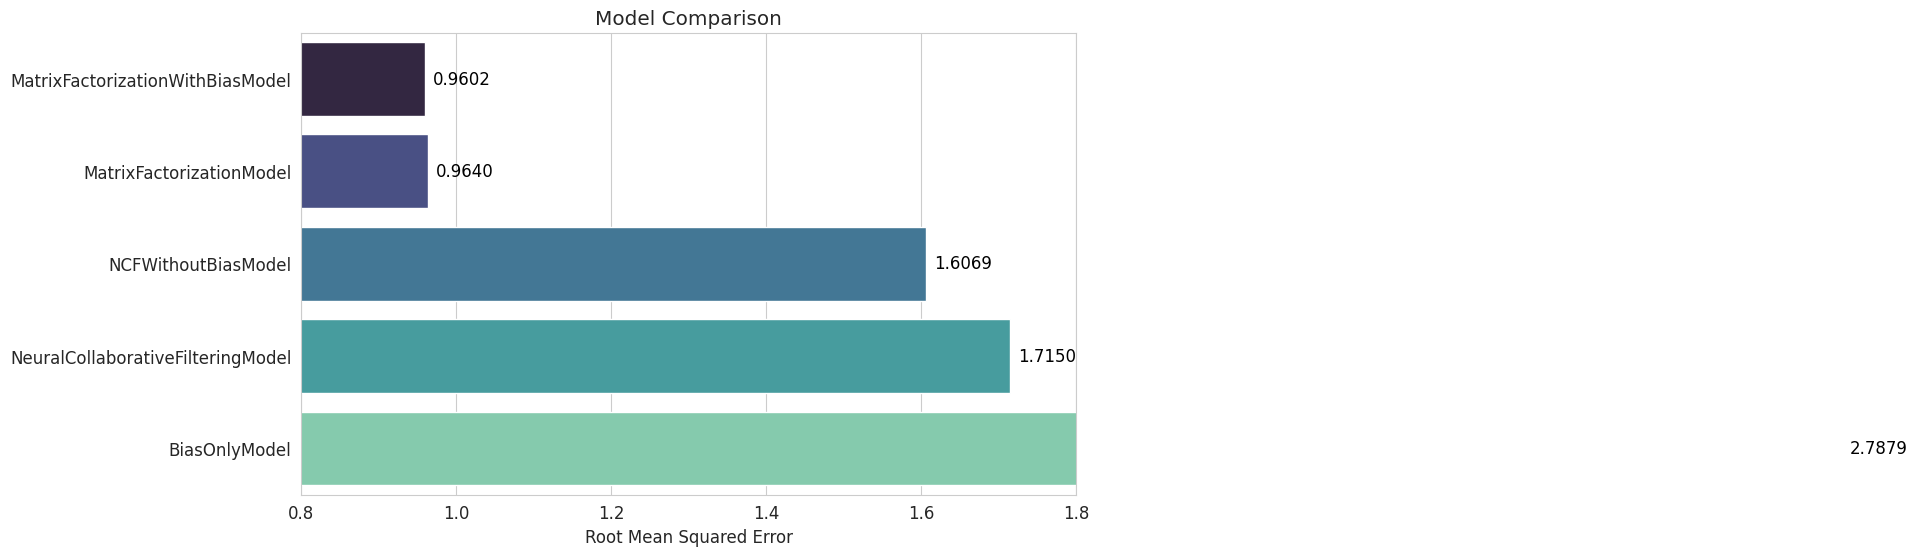

/tmp/ipython-input-950523399.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='dim', y='rmse', data=dim_performance, palette='viridis')


Plot 3 Saved: /content/drive/MyDrive/resources/processed_for_colab/embedding_analysis.png


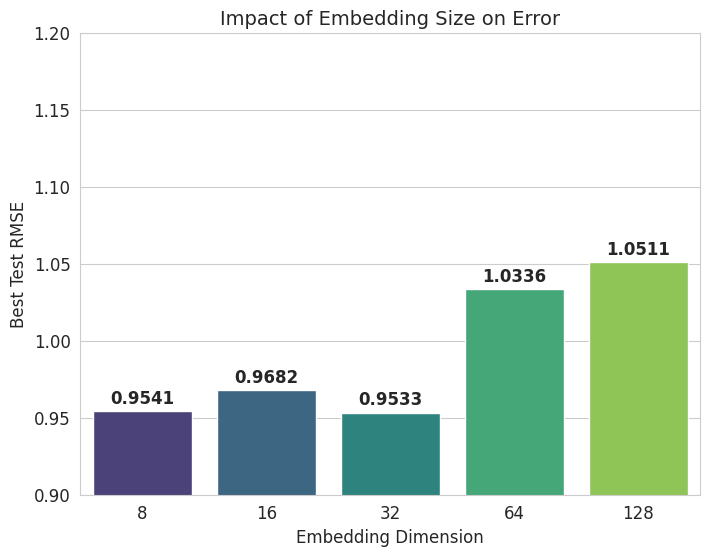

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df_grid = pd.DataFrame(grid_results)
    df_models = pd.DataFrame(model_results)
except NameError:
    # If variables are lost, load from the saved CSVs
    base_path = '/content/drive/MyDrive/resources/processed_for_colab'
    df_grid = pd.read_csv(f'{base_path}/grid_results.csv')
    df_models = pd.read_csv(f'{base_path}/model_comparison_results.csv')
print("data Loaded for visualization")

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

#heatmap for LR vs Reg
target_dim = 32
subset = df_grid[df_grid['dim'] == target_dim]

pivot_table = subset.pivot(index='lr', columns='reg', values='rmse')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis_r", linewidths=1)
plt.title(f'RMSE Heatmap (Fixed Dim={target_dim})')
plt.ylabel('Learning Rate')
plt.xlabel('Regularization')

save_path_1 = '/content/drive/MyDrive/resources/processed_for_colab/heatmap_lr_reg.png'
plt.savefig(save_path_1, bbox_inches='tight', dpi=300)
print(f"Plot 1 Saved: {save_path_1}")
plt.show()

#model comparasion
plt.figure(figsize=(10, 6))
df_models = df_models.sort_values('RMSE', ascending=True)

ax = sns.barplot(x='RMSE', y='Model', data=df_models, palette='mako')
plt.title('Model Comparison')
plt.xlabel('Root Mean Squared Error')
plt.ylabel('')
plt.xlim(0.8, 1.8)

for i, v in enumerate(df_models['RMSE']):
    ax.text(v + 0.01, i, f"{v:.4f}", color='black', va='center')

save_path_2 = '/content/drive/MyDrive/resources/processed_for_colab/model_comparison.png'
plt.savefig(save_path_2, bbox_inches='tight', dpi=300)
print(f"Plot 2 Saved {save_path_2}")
plt.show()

#embedding dim vs RMSE
plt.figure(figsize=(8, 6))

dim_performance = df_grid.groupby('dim')['rmse'].min().reset_index()

ax = sns.barplot(x='dim', y='rmse', data=dim_performance, palette='viridis')

plt.title('Impact of Embedding Size on Error', fontsize=14)
plt.xlabel('Embedding Dimension', fontsize=12)
plt.ylabel('Best Test RMSE', fontsize=12)
plt.ylim(0.9, 1.2)

for i, v in enumerate(dim_performance['rmse']):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

save_path_3 = '/content/drive/MyDrive/resources/processed_for_colab/embedding_analysis.png'
plt.savefig(save_path_3, bbox_inches='tight', dpi=300)
print(f"Plot 3 Saved: {save_path_3}")
plt.show()